In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
cars_data = pd.read_csv('Cardetails.csv')
cars_data.head(8)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,"7.8@ 4,500(kgm@ rpm)",5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,59Nm@ 2500rpm,4.0


In [3]:
cars_data.shape

(8128, 13)

In [4]:
cars_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [5]:
cars_data.drop(columns = ['torque'], inplace = True)

In [6]:
cars_data.head(8)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,4.0


In [7]:
cars_data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
seats            221
dtype: int64

In [8]:
cars_data.dropna(inplace = True)

In [9]:
cars_data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [10]:
cars_data.duplicated().sum()

np.int64(1189)

In [11]:
cars_data.drop_duplicates(inplace = True)

In [12]:
cars_data.shape

(6718, 12)

In [13]:
for col in cars_data.columns:
    print('Unique Values of ' +col)
    print(cars_data[col].unique())
    print('======================')

Unique Values of name
<ArrowStringArray>
[                      'Maruti Swift Dzire VDI',
                 'Skoda Rapid 1.5 TDI Ambition',
                     'Honda City 2017-2020 EXi',
                    'Hyundai i20 Sportz Diesel',
                       'Maruti Swift VXI BSIII',
                'Hyundai Xcent 1.2 VTVT E Plus',
                 'Maruti Wagon R LXI DUO BSIII',
                           'Maruti 800 DX BSII',
                             'Toyota Etios VXD',
         'Ford Figo Diesel Celebration Edition',
 ...
                    'Toyota Innova 2.5 E 7 STR',
                            'Honda City ZXi AT',
                 'Ford Fiesta 1.4 Duratorq EXI',
                           'Chevrolet Cruze LT',
                  'Maruti Celerio ZXI AMT BSIV',
                        'Tata Bolt Revotron XM',
           'Tata Manza Aura (ABS) Safire BS IV',
                   'Tata Nexon 1.5 Revotorq XT',
     'Ford Freestyle Titanium Plus Diesel BSIV',
 'Toyota Innova 2.5 GX 

In [14]:
def clean_data(value):
    if value is None or str(value).strip() == '':
        return ''
        
    # Extract the first word
    first_word = str(value).split(' ')[0].strip()
    
    # Try to make it a number; if it fails, keep it as text
    try:
        return float(first_word)
    except ValueError:
        return first_word

# Tests
print(clean_data('Maruti Swift Dzire VDI'))  # Outputs: 'Maruti'
print(clean_data('19.5 kmpl'))               # Outputs: 19.5
print(clean_data('1248 CC'))                 # Outputs: 1248.0


Maruti
19.5
1248.0


In [15]:
cars_data['name'] = cars_data['name'].apply(clean_data)

In [16]:
cars_data.head(8)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,5.0
6,Maruti,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,4.0


In [17]:
cars_data['mileage'] = cars_data['mileage'].apply(clean_data)

In [18]:
cars_data.sample(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
5130,Hyundai,2017,1150000,27000,Diesel,Individual,Manual,Second Owner,19.67,1582 CC,126.2 bhp,5.0
3940,Chevrolet,2016,160000,50000,Petrol,Individual,Manual,Second Owner,16.20,995 CC,62.1 bhp,5.0
2735,Mahindra,2016,750000,35000,Diesel,Individual,Manual,First Owner,18.49,1493 CC,100 bhp,7.0


In [19]:
cars_data['engine'] = cars_data['engine'].apply(clean_data)
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)

In [20]:
cars_data.sample(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
3774,Maruti,2016,700000,80000,Diesel,Dealer,Manual,First Owner,27.39,1248.0,74.0,5.0
6603,Tata,2013,500000,80000,Diesel,Individual,Manual,Second Owner,13.70,2179.0,138.1,7.0
6351,Tata,2017,350000,35000,Petrol,Individual,Manual,First Owner,17.57,1193.0,88.7,5.0
2835,Maruti,2015,575000,60000,Diesel,Dealer,Manual,First Owner,25.47,1248.0,88.5,7.0
6625,Tata,2018,400000,40000,Petrol,Individual,Manual,First Owner,23.84,1199.0,84.0,5.0


In [21]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   str    
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   str    
 5   seller_type    6718 non-null   str    
 6   transmission   6718 non-null   str    
 7   owner          6718 non-null   str    
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6718 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(3), int64(3), object(1), str(5)
memory usage: 945.4+ KB


In [22]:
cars_data['max_power'] = pd.to_numeric(cars_data['max_power'].astype(str).str.replace(' bhp', '').str.strip(), errors='coerce')

In [23]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   str    
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   str    
 5   seller_type    6718 non-null   str    
 6   transmission   6718 non-null   str    
 7   owner          6718 non-null   str    
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6718 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 945.4 KB


In [24]:
cars_data.dropna(inplace = True)

In [25]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   str    
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   str    
 5   seller_type    6717 non-null   str    
 6   transmission   6717 non-null   str    
 7   owner          6717 non-null   str    
 8   mileage        6717 non-null   float64
 9   engine         6717 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6717 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 946.1 KB


In [26]:
from sklearn.preprocessing import LabelEncoder

# Create a dictionary to hold unique encoders for each column
encoders = {}
cols_to_encode = ['name', 'fuel', 'seller_type', 'owner', 'transmission']

for col in cols_to_encode:
    encoders[col] = LabelEncoder()
    cars_data[col] = encoders[col].fit_transform(cars_data[col])

# Now you can check any column safely without overwriting!
# print(encoders['name'].classes_)
# print(encoders['owner'].classes_)

In [27]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   int64  
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   int64  
 5   seller_type    6717 non-null   int64  
 6   transmission   6717 non-null   int64  
 7   owner          6717 non-null   int64  
 8   mileage        6717 non-null   float64
 9   engine         6717 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6717 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 682.2 KB


In [28]:
cars_data.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,20,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0
1,26,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,10,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0
3,11,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,5.0
4,20,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,5.0


In [29]:
for col in cols_to_encode:
    print('Unique Values of ' +col)
    print(cars_data[col].unique())
    print('======================')

Unique Values of name
[20 26 10 11 28  9 25 19 27  4  6 14 21 22  2 29  3 23 17 13 16 18 30  5
 15  7  8  0  1 12 24]
Unique Values of fuel
[1 3 2 0]
Unique Values of seller_type
[1 0 2]
Unique Values of owner
[0 2 4 1 3]
Unique Values of transmission
[1 0]


In [30]:
lr = LinearRegression()

In [31]:
feature_cols = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 
                'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
X = cars_data[feature_cols]
y = cars_data['selling_price']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 1396.95,34932.75, -0.61,..., 62.28, 8635.34,-4322.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['name','year','km_driven',...,'engine','max_power','seats']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.02e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [34]:
y_pred = lr.predict(X_test)

In [35]:
y_pred

array([1518263.77923489,  697839.12591062,  238732.05918707, ...,
        392994.53239791,  897597.34946361,   42407.09547231],
      shape=(1344,))

In [36]:
y_test

7039     450000
5031     800000
2807      75000
1834    3200000
4945    1650000
         ...   
5173     325000
462      600000
1931     300000
1673    1300000
962      305000
Name: selling_price, Length: 1344, dtype: int64

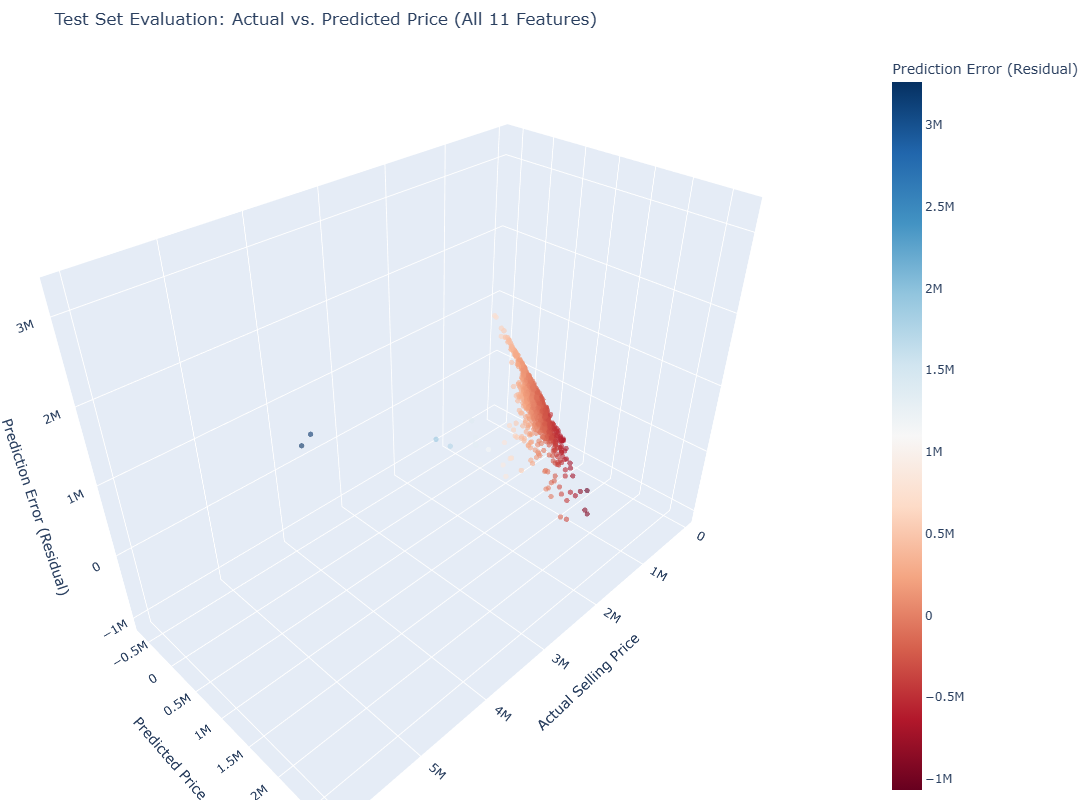

In [37]:
import pandas as pd
import plotly.express as px

test_results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

# 3. Calculate the prediction error (Residual)
test_results['Error'] = test_results['Actual Price'] - test_results['Predicted Price']

# 4. Plot the 3D chart using the new test_results DataFrame
fig = px.scatter_3d(
    test_results,
    x='Actual Price',
    y='Predicted Price',
    z='Error',
    color='Error',
    color_continuous_scale='RdBu',
    opacity=0.6,
    title='Test Set Evaluation: Actual vs. Predicted Price (All 11 Features)',
    labels={
        'Actual Price': 'Actual Selling Price',
        'Predicted Price': 'Predicted Price',
        'Error': 'Prediction Error (Residual)'
    }
)
fig.update_layout(
    width=1000, 
    height=800,
    margin=dict(l=0, r=0, b=0, t=50) 
)
fig.update_traces(marker=dict(size=3))
fig.show()


In [38]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("R2 score",r2_score(y_test,y_pred))
#An \(R^{2}\) score of 0.66 means your 11 features explain about 66% of the variance in car prices.

R2 score 0.6597275361174637


In [39]:
from sklearn.metrics import r2_score

# 1. Initialize the model
lr = LinearRegression()

# 2. Separate features and target
feature_cols = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 
                'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
X = cars_data[feature_cols]
y = cars_data['selling_price']

# 3. Split the data exactly as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Apply log transformation to the training target variable
y_train_log = np.log1p(y_train)

# 5. Fit the linear regression model using the log-scaled target
lr.fit(X_train, y_train_log)

# 6. Predict on the test features (this outputs log-scaled values)
y_pred_log = lr.predict(X_test)

# 7. Convert the log predictions back to original prices (Rupees)
y_pred = np.expm1(y_pred_log)

# 8. Check your new R² score
new_r2 = r2_score(y_test, y_pred)
print(f"Original R² Score: 0.6597")
print(f"New R² Score with Log Transform: {new_r2:.4f}")

Original R² Score: 0.6597
New R² Score with Log Transform: 0.8560


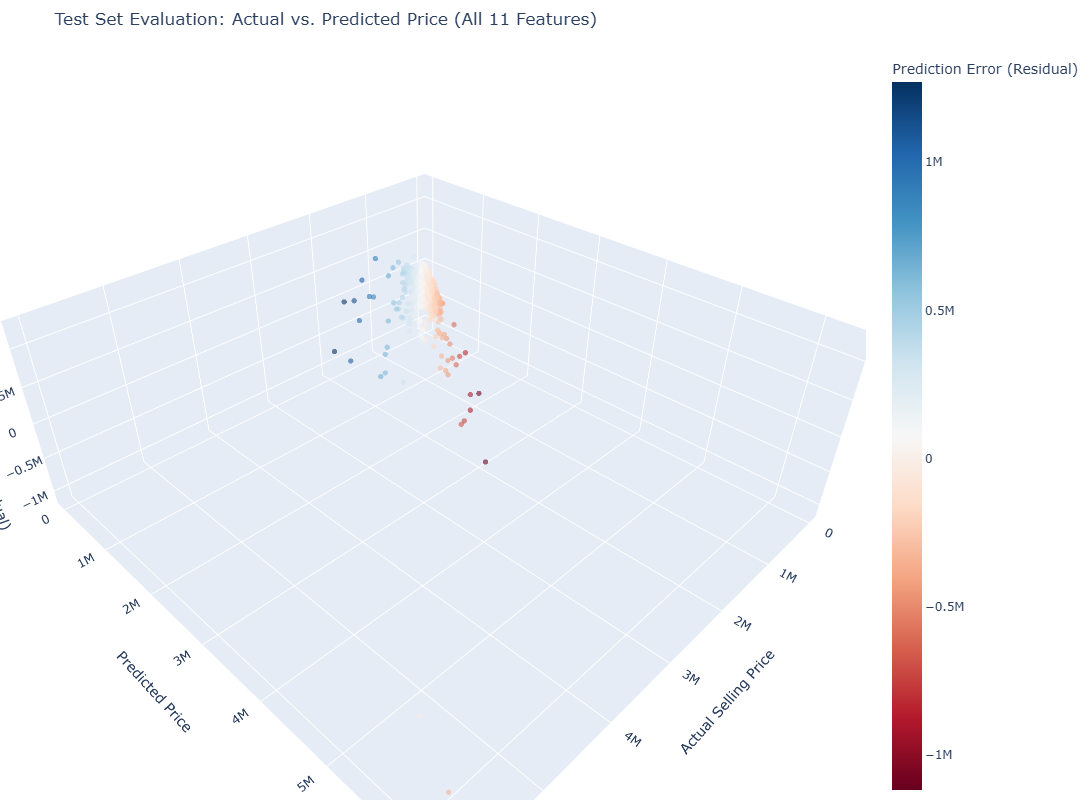

In [40]:
import plotly.express as px

test_results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

# 3. Calculate the prediction error (Residual)
test_results['Error'] = test_results['Actual Price'] - test_results['Predicted Price']

# 4. Plot the 3D chart using the new test_results DataFrame
fig = px.scatter_3d(
    test_results,
    x='Actual Price',
    y='Predicted Price',
    z='Error',
    color='Error',
    color_continuous_scale='RdBu',
    opacity=0.6,
    title='Test Set Evaluation: Actual vs. Predicted Price (All 11 Features)',
    labels={
        'Actual Price': 'Actual Selling Price',
        'Predicted Price': 'Predicted Price',
        'Error': 'Prediction Error (Residual)'
    }
)
fig.update_layout(
    width=1000, 
    height=800,
    margin=dict(l=0, r=0, b=0, t=50) 
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [ ]:
"""
Log transformation boosts your \(R^{2}\) score by fixing three main issues that break linear regression:

Compresses Outliers: Car prices are heavily right-skewed (mostly cheap cars with a few super-expensive ones). Log transformation pulls these massive 
luxury prices closer to the rest of the data. This shapes the target into a symmetrical Normal Distribution, preventing outliers from warping the 
model.

Flattens Exponential Decay: Cars do not lose value by a fixed rupee amount each year; they depreciate proportionally (e.g., losing 15% of their value 
annually). Log transformation mathematically converts this curved, exponential decay into a straight line that linear regression can easily map.

Balances the Error Spread: In your original model, errors on expensive cars were massive compared to cheap cars, creating an unstable "trumpet shape" 
on your chart. Log transformation forces the model to focus on percentage errors instead of absolute cash differences, stabilizing the error variance 
across all price ranges.

"""